1 : Fibonacci-Zahlen
Schreiben Sie eine Python-Funktion, die für gegebenes n die Fibonacci-Zahl fn berechnet. (Konvention:
f0 = 0, f1 = 1).

In [ ]:
def fib(n: int) -> int:
    """Rekursive Berechnung der n-ten Fibonacci-Zahl.

    Args:
        n (int): Index der Fibonacci-Zahl.

    Returns:
        int: Die n-te Fibonacci-Zahl.
    """
    if not isinstance(n, int):
        raise TypeError("n muss vom Typ int sein")
    if n < 0:
        raise ValueError("n darf nicht kleiner als null sein")
    if n == 0:
        return 0.0
    elif n == 1:
        return 1.0
    else:
        return fib(n - 1) + fib(n - 2)
    
print(" Die 10. Fibonacci-Zahl ist:", fib(10))

 Die 10. Fibonacci-Zahl ist: 55.0


2 : Schrittweise Propagation des harmonischen Oszillators

a: Durch Iteration dieser Gleichung kann eine Näherung der Dynamik berechnet werden. Implementieren
Sie diese Berechnung und erstellen Sie Schaubilder der beiden Lösungen sowie der
Trajektorie für mehrere Perioden in der q-p-Ebene (Phasenraum).

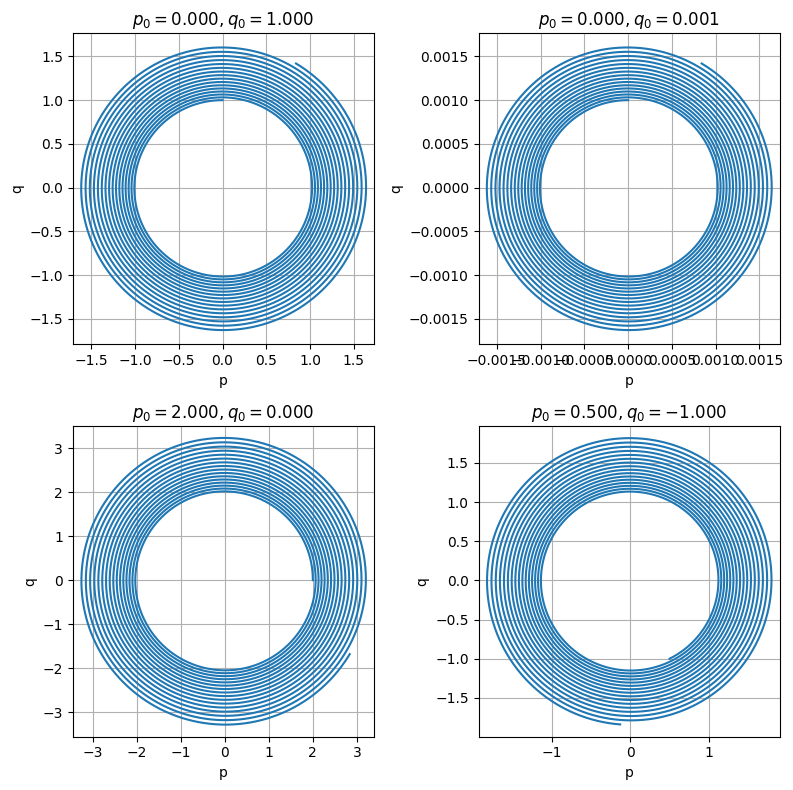

In [22]:
import matplotlib.pyplot as plt
from numpy import array, linspace

def oscillator_step(current_p: float, current_q: float, timestep = .01) -> tuple[float, float]:
    """Führt einen Zeitschritt für einen Oszillator durch.

    Args:
        current_p (float): Der aktuelle Impuls des Oszillators.
        current_q (float): Die aktuelle verallgemeinerte Position des Oszillators.
        timestep (float): Die Zeitdauer des Zeitschritts.

    Returns:
        NDArray[np.float64]: Der neue Zustand des Oszillators.
    """
    omega = 1.0
    new_q = current_q + omega * current_p * timestep
    new_p = current_p - omega * current_q * timestep
    return new_p, new_q

def simulate(p0: float, q0: float, t: array, dt: float):
    p_list, q_list = [p0], [q0]
    for _ in t[1:]:
        new_p, new_q = oscillator_step(p_list[-1], q_list[-1], dt)
        p_list.append(new_p); q_list.append(new_q)
    return array(p_list), array(q_list)

t = linspace(0, 100, 10000)
dt = t[1] - t[0]
starts = [(0., 1.0), (0., 0.001), (2.0, 0.0), (0.5, -1.0)]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
for ax, (p0, q0) in zip(axs.ravel(), starts):
    p, q = simulate(p0, q0, t, dt)
    ax.plot(p, q, '-')
    ax.set_title(r'$p_0=%.3f, q_0=%.3f$' % (p0, q0))
    ax.set_xlabel("p")
    ax.set_ylabel("q")
    ax.axis("equal")
    ax.grid(True)

plt.tight_layout()
plt.show()